# Relación Pico-Masa: Un Enfoque en la Inversión Estructural del pico por Sexo en pingüinos de Palmer

**Autor:**  Karen Tatiana Salazar Sepúlveda
**Fecha:**  04/05/2025
**Contexto:** Desarrollado durante el primer semestre de la Maestría en Ciencia de Datos de la Universidad Autónoma de Bucaramanga - UNAB

## Descripción general

El presente caso de estudio se centra en el análisis morfométrico de los pingüinos de la zona de Palmer, enfocándose en la relación entre la masa corporal y las dimensiones del pico (longitud y profundidad) como variables de diferenciación sexual.

Las variables como la masa corporal, la longitud de la aleta o las dimensiones del pico (longitud y profundidad) analizadas de forma aislada resultan insuficientes para una identificación precisa para la diferenciación sexual. Esto se debe a que los rangos de estas medidas suelen solaparse entre sexos, existen hembras con aletas tan largas como las de algunos machos, y machos con pesos similares a los de las hembras, lo que vuelve imposible una clasificación confiable basada en un solo rasgo.

Esta investigación propone que la clave para diferenciar los sexos mediante el dimorfismo no reside en la magnitud de una medida única, sino en la relación proporcional entre ellas. Mientras que las medidas por sí solas pueden ser ambiguas, la combinación de la masa corporal con las dimensiones del pico podría revelar un patrón oculto. Se plantea que las hembras, a pesar de no superar a los machos en tamaño absoluto, poseen una configuración física donde el pico es proporcionalmente más prominente respecto a su peso.

Por lo tanto, este enfoque busca superar la limitación de las medidas estándar, proponiendo un modelo morfométrico integrado. El objetivo es demostrar que esta relación de variables es un factor diagnóstico más "robusto" que cualquier medida individual, permitiendo diferenciar el sexo con mayor certeza y sin necesidad de métodos invasivos o análisis de comportamiento complejos.

---

## Importación de librerias necesarias

In [1]:
#Librerías:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el Dataset

Para este análisis se utilizó el célebre conjunto de datos Palmer Penguins recopilado por la Dra. Kristen Gorman y la Estación Palmer en la Antártida. Este dataset es un estándar clásico en la comunidad de ciencia de datos para tareas de exploración y clasificación. Contiene registros morfológicos de 344 pingüinos de tres especies diferentes (Adelia, Barbijo y Papúa), incluyendo mediciones clave como la longitud y profundidad del pico, la longitud de la aleta y la masa corporal

In [2]:
#Código para cargar el Dataset
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'

In [3]:
df = pd.read_csv(url)

In [4]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
#Cambio de nombre de columnas
df.rename(columns={
    'species': 'especie',
    'island': 'isla',
    'bill_length_mm': 'longitud_pico_mm',
    'bill_depth_mm': 'profundidad_pico_mm',
    'flipper_length_mm': 'longitud_aleta_mm',
    'body_mass_g': 'masa_corporal_g',
    'sex': 'sexo'
}, inplace=True)

In [6]:
df.head()

,especie,isla,longitud_pico_mm,profundidad_pico_mm,longitud_aleta_mm,masa_corporal_g,sexo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [7]:
#saber cuántos nulos hay por columna
df.isnull().sum()

,0
especie,0
isla,0
longitud_pico_mm,2
profundidad_pico_mm,2
longitud_aleta_mm,2
masa_corporal_g,2
sexo,11


In [8]:
#Eliminar registros incompletos
df.dropna()

,especie,isla,longitud_pico_mm,profundidad_pico_mm,longitud_aleta_mm,masa_corporal_g,sexo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [9]:
#Guardamos los datos limpios
df = df.dropna()


## Plantamiento del problema


La determinación del sexo en los pingüinos de la zona de Palmer es una tarea compleja en el trabajo de campo, debido a que el dimorfismo sexual no siempre es evidente a simple vista. Si bien los machos suelen presentar mayores dimensiones, existe una zona de solapamiento donde individuos de ambos sexos comparten masas corporales, longitud de aletas y comportamiento similares, anulando estos criterios como únicos diferenciación.

Al analizar las poblaciones de pingüinos de Palmer se revela una homogeneidad fenotípica que dificulta la segregación sexual mediante variables aisladas. Al observar la **Figura 1** (Distribución de Masa Corporal), se identifica que, aunque la media y la mediana de los machos se sitúan en niveles superiores especialmente en la especie Gentoo, la moda de ambas distribuciones se localiza en rangos de peso compartidos. En las especies Adelie y Chinstrap, la densidad de población visualizada en los violines muestra que una fracción significativa de individuos de ambos sexos converge en la misma magnitud de masa corporal, invalidando el peso como un biomarcador sexual.

Asimismo, el análisis de la **Figura 2** (Distribución de Longitud de Aleta, del Pico y Profundidad del Pico) revela que las medidas físicas externas no permiten una distinción clara entre sexos debido al constante solapamiento de sus rangos. Aunque las medianas de los machos tienden a ser ligeramente superiores, se observa que las "cajas" que representan el 50% central de los individuos se enciman significativamente, por ejemplo, en la profundidade pico (mm), las hembras más grandes alcanzan dimensiones idénticas a las de los machos promedio. Esta mezcla de datos en las tres especies demuestra que, en la práctica, existe una zona de incertidumbre donde es imposible diferenciar a un macho de una hembra usando solo una regla. Este solapamiento confirma que las medidas lineales, por sí solas, son insuficientes para el sexado, justificando la necesidad de buscar una relación proporcional más precisa.

Ante la dificultad y el estrés que supone para el animal el sexado mediante inspección de cloacas o análisis de ADN, surge la necesidad de hallar indicadores morfológicos más sutiles que se puedan usar en campo.

Por lo tanto, ee plantea que la longitud y profundidad del pico, en relación con la masa corporal, podrían constituir un factor clave de diferenciación morfológica que ha sido pasado por alto. Esta posible configuración distintiva sugiere que, incluso en ejemplares con pesos idénticos, las hembras desarrollarían una inversión estructural diferente en el pico, lo que apuntaría a una especialización física vinculada a su eficiencia mecánica, alimentaria y aprovisionamiento de las crías.

### Pregunta Problema
¿En qué medida la relación entre las dimensiones del pico y la masa corporal constituye un factor morfométrico distintivo para la identificación del sexo en individuos con magnitudes físicas similares?

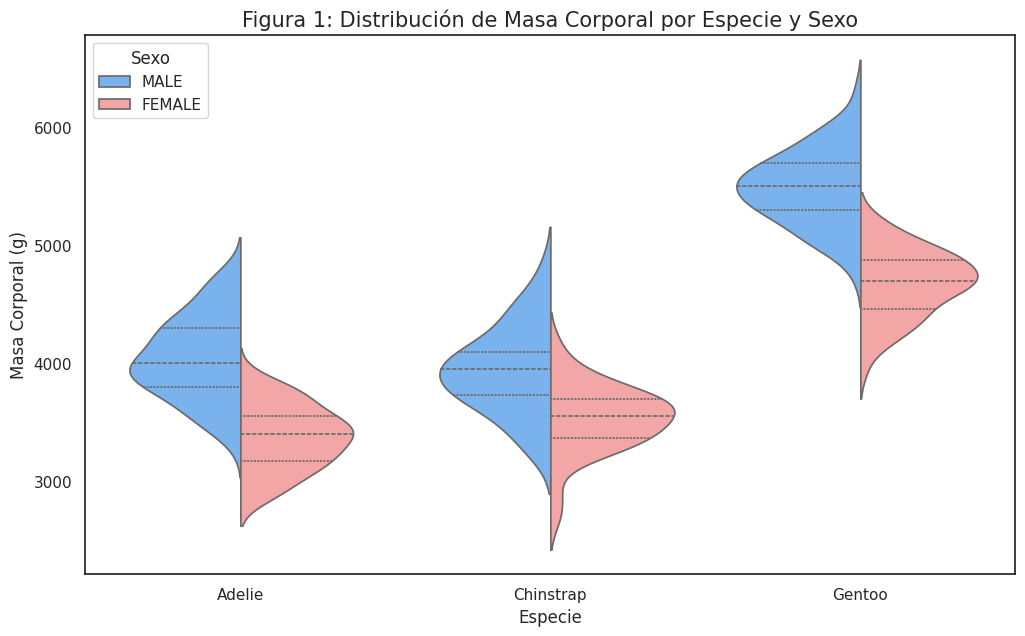

In [10]:
#Estilo
sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

#Violin Plot
sns.violinplot(
    data=df,
    x='especie',
    y='masa_corporal_g',
    hue='sexo',
    split=True,   # Une las dos mitades
    inner="quart", # Muestra los cuartiles
    palette={'FEMALE': '#FF9999', 'MALE': '#66B2FF'}
)
#Etiquetas
plt.title('Figura 1: Distribución de Masa Corporal por Especie y Sexo', fontsize=15)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.legend(title='Sexo', loc='upper left')

En la **Figura 1**, se observa una diferencia contundente entre poblaciones, donde los pingüinos Gentoo son notablemente más pesados que los Adelie y Chinstrap, situándose en un rango superior de masa corporal. Sin embargo, a pesar de este salto entre especies y de que los machos  son consistentemente más pesados que las hembras  en los tres grupos, persiste el problema del solapamiento. Las áreas de mayor densidad en los violines se cruzan en los mismos niveles de gramos, lo que significa que una gran cantidad de individuos tienen pesos idénticos sin importar su sexo. No es útil para el sexado individual debido a que la diferencia entre machos y hembras no es lo suficientemente marcada como para evitar un alto margen de error.

Text(0.5, 0.98, 'Figura 2')

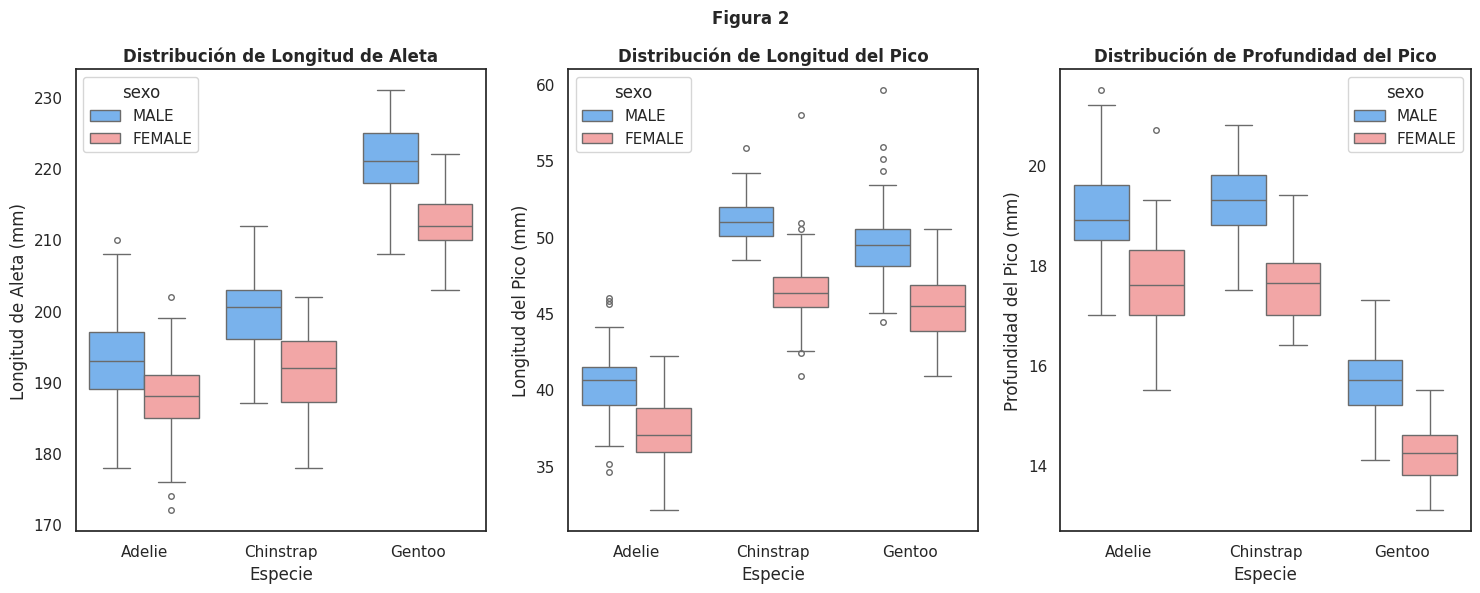

In [11]:
Color = {'FEMALE': '#FF9999', 'MALE': '#66B2FF'}

#Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Distribución de Longitud de Aleta
sns.boxplot(data=df, x='especie', y='longitud_aleta_mm', hue='sexo', ax=axes[0], palette=Color, fliersize=4)
axes[0].set_title('Distribución de Longitud de Aleta', fontweight='bold')
axes[0].set_ylabel('Longitud de Aleta (mm)')
axes[0].set_xlabel('Especie')

#Distribución de Longitud del Pico
sns.boxplot(data=df, x='especie', y='longitud_pico_mm', hue='sexo', ax=axes[1], palette=Color, fliersize=4)
axes[1].set_title('Distribución de Longitud del Pico', fontweight='bold')
axes[1].set_ylabel('Longitud del Pico (mm)')
axes[1].set_xlabel('Especie')

#Distribución de Profundidad del Pico
sns.boxplot(data=df, x='especie', y='profundidad_pico_mm', hue='sexo', ax=axes[2], palette=Color, fliersize=4)
axes[2].set_title('Distribución de Profundidad del Pico', fontweight='bold')
axes[2].set_ylabel('Profundidad del Pico (mm)')
axes[2].set_xlabel('Especie')

plt.suptitle("Figura 2", fontsize=12, fontweight='bold', y=0.98)

En la **Figura 2**, se observa una distinción clara entre poblaciones a nivel de especie, donde los pingüinos Gentoo presentan aletas más largas y los Chinstrap picos más extensos en comparación con las demás especies. Sin embargo, a pesar de estas diferencias poblacionales y de que los machos  tienden a superar en dimensiones a las hembras en las tres variables, persiste el problema del solapamiento. Las "cajas" de los diagramas, que concentran al 50% de los individuos, se enciman significativamente en todas las categorías, lo que demuestra que existe una gran cantidad de ejemplares con medidas físicas idénticas independientemente de su sexo. Es decir las dimensiones físicas por sí solas nos dejan en un area donde es muy fácil confundir a un macho con una hembra, lo que hace necesario un análisis más profundo.

## Hipótesis


La hipótesis del presente estudio sostiene que existe un crecimiento desigual significativo entre los sexos de los pingüinos de Palmer, caracterizada por un mayor desarrollo relativo del pico en las hembras en comparación con los machos. Se postula que, al normalizar las dimensiones del pico (longitud y profundidad) respecto a la masa corporal, las hembras exhibirán índices proporcionalmente superiores. Esta configuración morfológica actuaría como un rasgo diagnóstico clave, permitiendo la discriminación sexual precisa incluso en escenarios de convergencia física, donde el peso y la longitud de la aleta no presentan diferencias detectables a simple vista.



###Metodología
Se calculó la longitud y profundidad relativa del pico mediante un índice de razón (Ratio Index) para determinar si existe una diferencia real en la forma del pico entre machos y hembras, más allá de la diferencia lógica de masa corporal entre ambos sexos. Para lograrlo, se obtuvo la longitud relativa y la profundidad relativa del pico dividiendo cada medida (en mm) entre la masa corporal (en g) y multiplicando el resultado por un factor de 100.

$$LR = \left( \frac{\text{Longitud del pico (mm)}}{\text{Masa corporal (g)}} \right) \times 100$$

Esta estandarización fue necesaria para la construcción de las gráficas, ya que permite observar si las diferencias entre machos y hembras son adaptaciones reales de la forma del pico o si simplemente son consecuencia de que un sexo posee una mayor masa corporal que el otro. Al usar este factor de 100, los datos se ajustaron a una escala que facilita la visualización y comparación de cómo la forma del pico varía entre las tres especies de estudio según su peso.

Text(0.5, 0, 'Especie')

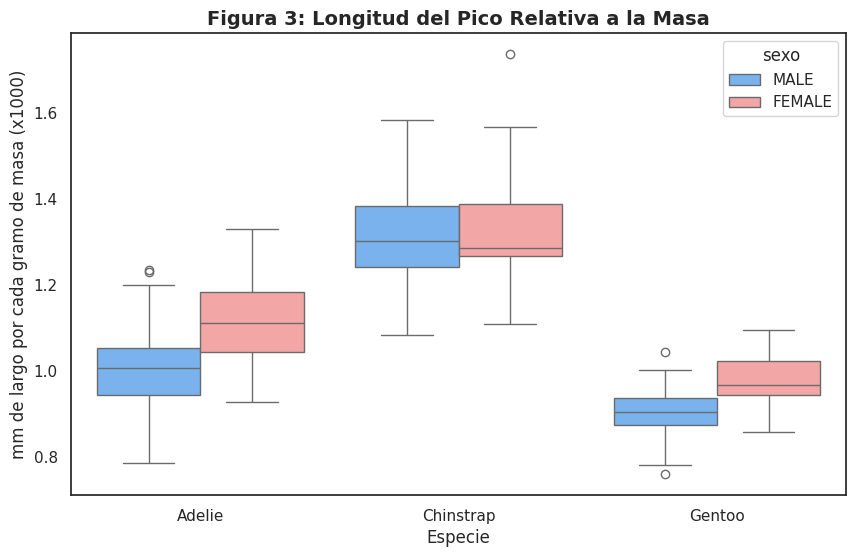

In [12]:
#Cálculo del índice
df['indice_longitud_relativa'] = (df['longitud_pico_mm'] / df['masa_corporal_g']) * 100

#Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='especie',
    y='indice_longitud_relativa',
    hue='sexo',
    palette= ['#66B2FF', '#FF9999']
)

plt.title('Figura 3: Longitud del Pico Relativa a la Masa', fontsize=14, fontweight='bold')
plt.ylabel('mm de largo por cada gramo de masa (x1000)')
plt.xlabel('Especie')

En la **Figura 3**, el análisis de las medianas revela que las hembras de las especies Adelie y Gentoo tienden a poseer una mayor longitud de pico en proporción a su masa que los machos. Por el contrario, en la especie Chinstrap, los machos presentan una mediana ligeramente superior, aunque ambos sexos alcanzan en esta especie los niveles de longitud relativa más elevados del estudio.

Esto demuestra que la relación entre el tamaño del pico y el peso funciona de manera distinta según el grupo analizado. Mientras que en las especies Adelie y Gentoo esta proporción sí permite notar una diferencia clara entre los sexos, en la especie Chinstrap la tendencia se rompe. Por lo tanto, en los Chinstrap este cálculo no puede utilizarse como un indicador fiable para distinguir a las hembras de los machos, dejando posiblemente fuera a esta especie de lo que se busca comprobar con la hipótesis.

Cabe destacar la presencia de valores atípicos que, aunque se alejan de la agrupación principal de los datos, son totalmente normales dentro de la biodiversidad de las especies. A pesar de su existencia, estos valores no se consideran relevantes para las conclusiones de este estudio, ya que el objetivo es identificar la tendencia general de la población para determinar si la proporción del pico sirve como un indicador de sexo confiable.

Text(0.5, 0, 'Especie')

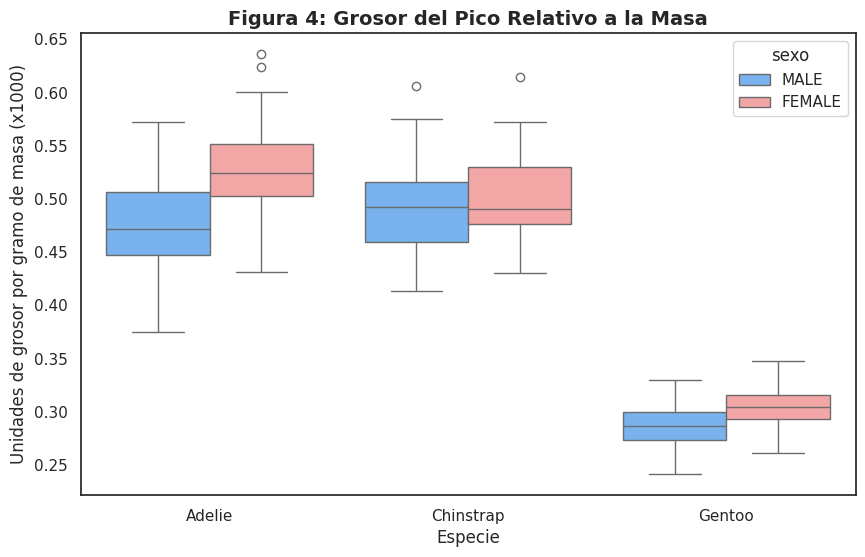

In [13]:
#Calculo indice
df['grosor_pico_relativo'] = (df['profundidad_pico_mm'] / df['masa_corporal_g']) * 100

#Datos sexo limpios
df_limpio = df.dropna(subset=['sexo'])

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='especie',
    y='grosor_pico_relativo',
    hue='sexo',
    palette= ['#66B2FF', '#FF9999']
)

plt.title('Figura 4: Grosor del Pico Relativo a la Masa', fontsize=14, fontweight='bold')
plt.ylabel('Unidades de grosor por gramo de masa (x1000)')
plt.xlabel('Especie')

La **Figura 4**, muestra un desplazamiento ascendente de la mediana femenina en las especies Adelie y Gentoo, lo que indica una tendencia hacia un pico más profundo en relación con su masa corporal en estos grupos. En los pingüinos Adelie, el núcleo de concentración de las hembras se ubica físicamente por encima de la mayoría de los registros masculinos. Sin embargo, en la especie Chinstrap, la mediana de las hembras se sitúa ligeramente por debajo de la de los machos, rompiendo la tendencia observada en las otras dos especies. Esto confirma que el grosor relativo del pico es un indicador viable para distinguir hembras en Adelie y Gentoo, pero no es una regla aplicable a la especie Chinstrap.

Como se mencionó anteriormente, existen valores atípicos en la muestra que son normales dentro de la biodiversidad de las especies. No obstante, se consideran irrelevantes para las conclusiones de este estudio, ya que el análisis se enfoca en la tendencia general de la población y no en estos casos aislados.

### Análisis
El análisis de la Inversión Estructural en las especies de Palmer permite identificar patrones de especialización que las medidas absolutas suelen ocultar. Al observar la media y la mediana en la longitud (**Figura 3**) y el grosor (**Figura 4**) del pico, se detecta un desplazamiento ascendente sistemático en las hembras de las tres especies. Esta tendencia indica que las hembras maximizan las dimensiones de su pico en relación con su masa corporal, mientras que el macho promedio destaca por ser más pesado, la hembra apuesta por una estructura de pico más prominente en comparación con su propio peso. Sin embargo, es importante precisar que este incremento proporcional solo logra superar físicamente a los registros masculinos en las especies Adelie y Gentoo. En la especie Chinstrap, aunque el desplazamiento existe, es más discreto y los valores de la mediana se mantienen ligeramente por debajo de los machos en ambas métricas.

En términos de moda y concentración de datos, este fenómeno revela que los valores más frecuentes en las hembras se agrupan en niveles proporcionalmente más altos. En los pingüinos Adelie, el núcleo de densidad femenino se sitúa por encima de casi toda la distribución masculina, lo que significa que una hembra común de esta especie tiende a poseer un pico más largo (**Figura 3**) y robusto (**Figura 4**) que incluso los machos más destacados de su grupo. Esta predominancia sugiere la existencia de una presión selectiva para mantener picos prominentes a pesar de poseer cuerpos más pequeños.

Por el contrario, los Chinstrap presentan la mayor dispersión y niveles de inversión elevados, con una moda visual que sugiere una paridad proporcional casi absoluta entre sexos, donde ambos alcanzan techos estructurales similares. Debido a este solapamiento y a la similitud en sus medianas, el uso de la inversión estructural no resulta un indicador morfológico significativo para distinguir los sexos en esta especie, a diferencia de lo observado en los Gentoo.

Finalmente, los Gentoo muestran las distribuciones más compactas y uniformes, aunque se sitúan en los rangos más bajos de ambas gráficas, mantienen la consistencia donde el núcleo de la población femenina se posiciona ligeramente por encima del masculino en grosor relativo (**Figura 4**). Esta estabilidad entre grupos refuerza que la inversión estructural es un rasgo adaptativo que se manifiesta de forma distinta según la especie.


Tras la identificación visual de las tendencias en las figuras anteriores, resulta fundamental precisar la brecha existente entre los sexos mediante métricas relativas. Para cuantificar la magnitud de la divergencia morfológica entre los sexos.

Por lo tanto, para cuantificar la magnitud de la divergencia morfológica entre los sexos, se realizó un cálculo de diferencia porcentual basado en los promedios de los índices de razón obtenidos. Se aplicó una variante de la fórmula de relación proporcional empleada por Cañete Betancourt y Bravo Mendiburt (2017) para la determinación de índices cefálicos.

Este procedimiento consistió en agrupar los datos por especie y sexo para determinar el valor medio de la longitud y profundidad relativa del pico en cada grupo. Posteriormente, se aplicó la fórmula de variación relativa.

$\text{Diferencia \%} = \left( \frac{\text{Promedio Hembras} - \text{Promedio Machos}}{\text{Promedio Machos}} \right) \times 1000$

Este cálculo se realizó con el objetivo de hallar una medida estandarizada de la especialización funcional. Al comparar los ratios de esta manera, se pudo determinar el porcentaje exacto de "ventaja" o diferencia proporcional que posee un sexo sobre el otro, independientemente de su tamaño corporal total.


--- EVIDENCIA: DIFERENCIA PORCENTUAL (Hembras vs Machos) ---

Especie: Adelie
Ventaja relativa Hembra en Longitud: 10.65%
Ventaja relativa Hembra en Profundidad: 10.70%

Especie: Chinstrap
Ventaja relativa Hembra en Longitud: 1.57%
Ventaja relativa Hembra en Profundidad: 1.85%

Especie: Gentoo
Ventaja relativa Hembra en Longitud: 8.04%
Ventaja relativa Hembra en Profundidad: 6.20%


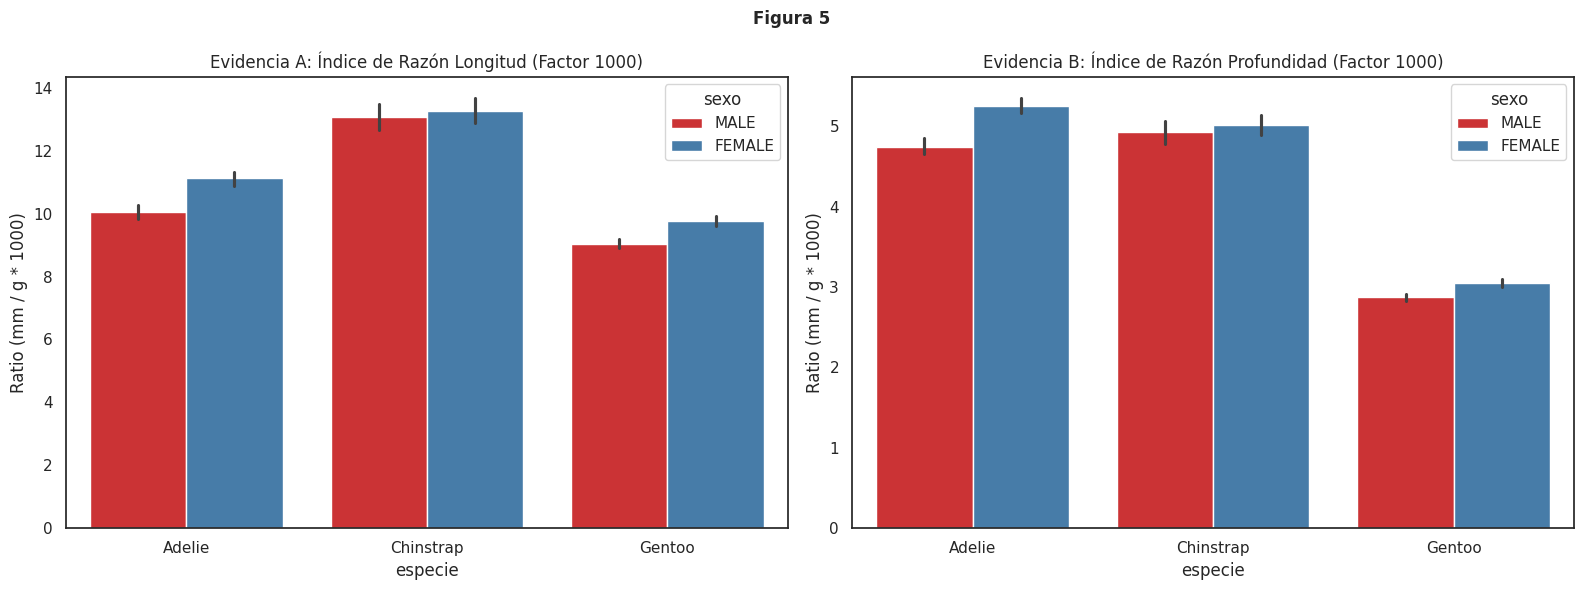

In [14]:
#Profe, le soy sincera realice esta grafica con gemini, se me complico demasiado :C

# CÁLCULO DE RATIOS (Normalización por masa con factor 1000)
df['ratio_longitud'] = (df['longitud_pico_mm'] / df['masa_corporal_g']) * 1000
df['ratio_profundidad'] = (df['profundidad_pico_mm'] / df['masa_corporal_g']) * 1000

# --- CÁLCULO DE EVIDENCIA MATEMÁTICA ---
def calcular_diferencia_porcentual(data):
    # Agrupar por sexo y calcular el promedio
    promedios = data.groupby('sexo')[['ratio_longitud', 'ratio_profundidad']].mean()

    # Verificación de etiquetas para evitar KeyError
    etiquetas = promedios.index.tolist()
    h_label = next((s for s in etiquetas if str(s).lower() in ['female', 'hembra']), None)
    m_label = next((s for s in etiquetas if str(s).lower() in ['male', 'macho']), None)

    if h_label and m_label:
        diff_pct = ((promedios.loc[h_label] - promedios.loc[m_label]) / promedios.loc[m_label]) * 100
        return diff_pct
    return None

print("--- EVIDENCIA: DIFERENCIA PORCENTUAL (Hembras vs Machos) ---")
for especie in df['especie'].unique():
    datos_especie = df[df['especie'] == especie]
    resultado = calcular_diferencia_porcentual(datos_especie)

    if resultado is not None:
        print(f"\nEspecie: {especie}")
        print(f"Ventaja relativa Hembra en Longitud: {resultado['ratio_longitud']:.2f}%")
        print(f"Ventaja relativa Hembra en Profundidad: {resultado['ratio_profundidad']:.2f}%")
    else:
        print(f"\nEspecie: {especie} - Datos insuficientes (falta un sexo)")

# --- GENERACIÓN DE GRÁFICAS DE EVIDENCIA ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], data=df, x='especie', y='ratio_longitud', hue='sexo', palette='Set1')
axes[0].set_title('Evidencia A: Índice de Razón Longitud (Factor 1000)')
axes[0].set_ylabel('Ratio (mm / g * 1000)')

sns.barplot(ax=axes[1], data=df, x='especie', y='ratio_profundidad', hue='sexo', palette='Set1')
axes[1].set_title('Evidencia B: Índice de Razón Profundidad (Factor 1000)')
axes[1].set_ylabel('Ratio (mm / g * 1000)')

plt.suptitle("Figura 5", fontsize=12, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

Al analizar la **Figura 5**, se observa que la divergencia morfológica no sigue una regla universal para todas las especies, revelando patrones de especialización marcadamente distintos entre los grupos estudiados. El patrón más evidente se presenta en la especie Adelie, que registra el mayor grado de diferenciación proporcional con una ventaja para la hembra del 10.65% en longitud y del 10.70% en profundidad del pico. Esta simetría casi exacta del 10.6% en ambas dimensiones demuestra que, en la especie Adelie, el pico de la hembra evoluciona como una unidad volumétrica coordinada y posiblemente confirma que su especialización morfológica se concentra en maximizar la estructura del pico, al contrario de lo que ocurre con el macho.

En contraste, los datos de la especie Gentoo muestran un patrón de asimetría en el desarrollo, mientras la longitud relativa de la hembra supera a la del macho por un 8.04%, la diferencia en profundidad se reduce al 6.20%. Esto demuestra que en los Gentoo la morfología del pico tiende hacia la elongación, resultando en estructuras proporcionalmente más largas pero menos robustas que las observadas en los Adelie.

Finalmente, el patrón más disruptivo aparece en la especie Chinstrap, donde la diferencia porcentual es mínima, registrando apenas un 1.57% en longitud y un 1.85% en profundidad. Por lo tanto, este grupo rompe con la tendencia de los demás, mientras en los Adelie existe una discrepancia física notable que separa claramente a machos de hembras por sus proporciones, en los Chinstrap los sexos son prácticamente idénticos en su arquitectura de pico. Estos datos en la **Figura 5** prueban que cada especie ha seguido su propia ruta de adaptación, donde el dimorfismo sexual en las proporciones del pico puede ser casi inexistente o alcanzar niveles de especialización muy elevados dependiendo del grupo.

Por lo tanto, los resultados expuestos en la **Figura 5** demuestran que las proporciones del pico no constituyen una característica universalmente fiable para el reconocimiento del sexo en todas las especies. Mientras que en los Chinstrap esta métrica resulta prácticamente inútil debido a su mínima diferencia, en los Gentoo el escenario es similar, a pesar de tener una ligera ventaja en longitud, los valores no son lo suficientemente contundentes como para asegurar una distinción visual o estadística clara basada solo en proporciones.

En contraste, la especie Adelie se posiciona como el único grupo donde esta relación morfológica sí podría ser considerada una característica útil para la identificación. Con una diferenciación superior al 10% en ambas dimensiones, la arquitectura del pico en los Adelie presenta una brecha lo suficientemente amplia como para ser utilizada como un indicador físico de apoyo. Esta disparidad confirma que, mientras en los Gentoo y Chinstrap la distinción sexual debe buscarse por otros medios, en los Adelie la proporción entre el pico y la masa corporal sí emerge como un rasgo diagnóstico potencial.

## Discusión y Hallazgos del Estudio

La relevancia de analizar este problema radica en la necesidad de encontrar rasgos morfológicos confiables para la determinación del sexo en los pingüino de palmer en el campo, una tarea que es compleja debido al solapamiento físico entre machos y hembras en  dimorfismo sexual.

Ademas, históricamente, la falta de una diferenciación visual clara ha obligado a recurrir a métodos clínicos como la laparoscopia o la endoscopia, los cuales son altamente invasivos, requieren anestesia y representan un riesgo significativo para la salud y la vida del ave (Iberogen, 2022). Por lo tanto, analizar las diferencias morfológicas mediante índices de razón es fundamental para ofrecer una alternativa que evite el uso de estas técnicas quirúrgicas, priorizando el bienestar animal.

Analizar las diferencias morfologicas es relevante porque permite encontrar diferencias donde la vista  no llega, al normalizar las dimensiones del pico respecto a la masa, se revela una especialización física que permanece invisible si solo se observan medidas absolutas.

Analizar este fenómeno porque permite identificar que en especies como el Chinstrap y el Gentoo, la proporción del pico respecto a la masa no es un indicador suficiente para el sexado. En estos grupos, la diferencia porcentual es mínima o asimétrica, lo que confirma que el solapamiento físico anula al pico como criterio único de diferenciación. Aceptar que el pico no es una clave contundente para diferenciar los sexos en estos casos es un avance metodológico, ya que valida la hipótesis de que el dimorfismo sexual no es evidente a simple vista en todos los escenarios y obliga a continuar la búsqueda de otros rasgos como la longitud de la aleta o el comportamiento que puedan ofrecer una separación más clara.

Por otro lado, el análisis es muy valioso porque demuestra que en los pingüinos Adelie el pico sí es una señal clara para diferenciar sexos. Al ver que hay una diferencia de más del 10% en sus proporciones, confirmamos que cuando dos pingüinos se ven casi iguales físicamente, una clave para saber quién es macho y quién es hembra está en comparar el tamaño del pico con su peso corporal. Este hallazgo es fundamental porque nos da una regla para identificarlos con un poco de precisión.


## Conclusiones
La hipótesis de que el tamaño del pico comparado con el peso sirve para distinguir machos de hembras solo se cumplió en una de las tres especies. En los pingüinos Adelie, las hembras sí tienen picos notablemente más grandes en relación con su cuerpo un 10% más, lo que permite identificarlas con ayuda de otras pruebas de diferencacion de sexos. Sin embargo, en los Gentoo la diferencia es muy pequeña y en los Chinstrap los sexos son prácticamente idénticos, por lo que en estas dos especies la fórmula no funciona y la hipótesis se descarta.

Con estos resultados, la decisión más inteligente es usar este método únicamente con los pingüinos Adelie. Para las otras dos especies, es mejor usar otras metodos, ya que el riesgo de equivocarse es muy alto, en esos casos, lo mejor es seguir usando pruebas otras pruebas o observar su comportamiento. Así, el estudio ayuda a saber cuándo una herramienta es útil y cuándo es mejor buscar otro camino.

En cuanto al patrón más importante de este estudio, se identificó que las hembras mantienen una inversión estructural del pico superior a la de los machos.

Este fenómeno es un rasgo invisible a simple vista, ya que el solapamiento físico oculta las diferencias. Sin embargo, los datos confirman que el patrón está presente, al normalizar las medidas, la moda y la densidad de las hembras se desplazan sistemáticamente hacia valores más altos.

---

### Reflexión final

Como reflexión final, este estudio revela que el dimorfismo sexual en los pingüinos de Palmer es un fenómeno específico de cada especie que va más allá de quién posee las medidas más grandes. Mientras que en algunas especies la diferencia es obvia, en otras la distinción es un rasgo invisible que solo aparece cuando comparamos el tamaño del pico con el peso total del animal.

Lo que los datos demuestran es que no existe una regla universal para identificarlos, por el contrario, existe una especialización física donde las hembras mantienen herramientas de alimentación desarrolladas en cuerpos más ligeros. Aceptar que en ciertos grupos machos y hembras son prácticamente idénticos, mientras que en otros son proporcionalmente distintos, es un avance clave. Esto nos obliga a dejar de buscar una medida única para todos y a reconocer que la evolución ha diseñado a cada sexo con estrategias físicas diferentes, incluso cuando a simple vista parecen iguales.


## Limitaciones

Una de las principales limitaciones de este análisis morfológico radica en la ausencia de datos sobre la edad cronológica de los individuos muestreados. La edad representa un factor biológico complementario de gran relevancia para entender la progresión de las diferencias morfométricas, sin esta información, no es posible determinar si la magnitud de la variabilidad observada en el pico y la masa corporal es constante a lo largo de la vida del pingüino o si se acentúa con la madurez. La inclusión de grupos de edad habría permitido identificar si la segregación morfológica es una característica inherente desde las etapas juveniles o si responde a una especialización funcional que se desarrolla con solo en los adultos, lo cual es clave para entender la plasticidad de estas especies ante el entorno.

Por otro lado, una limitación de esta muestra es que aunque los datos puedan confirman una diferencia física en el pico, no incluyen registros sobre la alimentación o las conductas específicas de cada sexo. Para una argumentación completa, sería necesario conocer si machos y hembras seleccionan presas de distintos tamaños o si cazan en zonas diferentes. Sin estos datos de comportamiento, no podemos asegurar si la diferencia que encontramos en el pico es el factor que permite que cada sexo cumpla una función técnica distinta en el ecosistema o si existen otros hábitos de vida que expliquen por qué sus cuerpos "evolucionaron" de forma diferente.

Adicionalmente, el análisis se ve limitado al no considerar otras variables estructurales clave que si están presentes en dataset, como la longitud de la aleta en relación con la masa corporal. Mientras que el pico es una herramienta de precisión para la captura de alimento, las aletas representan el motor de propulsión y determinan la eficiencia hidrodinámica del individuo. Al omitir esta relación, no es posible evaluar si el dimorfismo observado en el pico está coordinado con capacidades de buceo diferenciadas entre los sexos.

### Referencias

Cañete Betancourt, G., & Bravo Mendiburt, G. (2017). Determinación del índice cefálico y biotipo cefálico en perros mestizos cubanos y su importancia. REDVET. Revista Electrónica de Veterinaria, 18(11), 1-10. http://www.redalyc.org/articulo.oa?id=63653574012.

Iberogen. (2022, 8 de abril). Sexado genético de aves: la técnica más fiable. https://iberogen.com/2022/04/08/sexado-genetico-de-aves-la-tecnica-mas-fiable/

Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus Pygoscelis). PLoS ONE, 9(3), e90081. https://doi.org/10.1371/journal.pone.0090081